In [1]:
from google.colab import drive
drive.mount('/content/drive')

import joblib
X_train = joblib.load('/content/drive/MyDrive/home_credit/X_train.pkl')
X_test = joblib.load('/content/drive/MyDrive/home_credit/X_test.pkl')
y_train = joblib.load('/content/drive/MyDrive/home_credit/y_train.pkl')
y_test = joblib.load('/content/drive/MyDrive/home_credit/y_test.pkl')

print("Loaded. Shapes:", X_train.shape, X_test.shape)

Mounted at /content/drive
Loaded. Shapes: (246008, 101) (61503, 101)


RANDOMFOREST

In [ ]:
# @title
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)   # NOTE: unscaled X_train, not X_train_scaled

print("Random Forest trained.")

Random Forest trained.


In [ ]:
# @title
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print("Random Forest ROC-AUC:", auc_rf)
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest ROC-AUC: 0.7282155961232323
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.53      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.73      0.50      0.48     61503
weighted avg       0.89      0.92      0.88     61503

[[56531     7]
 [ 4957     8]]


In [ ]:
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

# Instead of the default 0.5 cutoff, try a lower threshold
y_pred_rf_adjusted = (y_pred_proba_rf > 0.15).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf_adjusted))


              precision    recall  f1-score   support

           0       0.94      0.91      0.92     56538
           1       0.24      0.34      0.28      4965

    accuracy                           0.86     61503
   macro avg       0.59      0.62      0.60     61503
weighted avg       0.88      0.86      0.87     61503



XGBOOST

In [ ]:
# Only run this if xgboost isn't already installed
!pip install xgboost --quiet


In [4]:
from xgboost import XGBClassifier

# scale_pos_weight is XGBoost's equivalent of class_weight='balanced'
# It should roughly equal (number of 0s) / (number of 1s) in your training data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)
xgb.fit(X_train, y_train)

print("XGBoost trained.")

scale_pos_weight: 11.38710976837865
XGBoost trained.


In [5]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

y_pred_xgb = xgb.predict(X_test)
y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]

auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print("XGBoost ROC-AUC:", auc_xgb)
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))


XGBoost ROC-AUC: 0.7488676813252569
              precision    recall  f1-score   support

           0       0.96      0.74      0.84     56538
           1       0.17      0.62      0.27      4965

    accuracy                           0.73     61503
   macro avg       0.57      0.68      0.55     61503
weighted avg       0.89      0.73      0.79     61503

[[41920 14618]
 [ 1885  3080]]


In [6]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_grid = {
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=20,          # try 20 random combinations
    scoring='roc_auc',  # optimize for ROC-AUC specifically
    cv=3,                # 3-fold cross-validation for each combination
    random_state=42,
    verbose=2
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV ROC-AUC:", random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=7, n_estimators=300, subsample=0.7; total time=  47.3s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=7, n_estimators=300, subsample=0.7; total time=  20.6s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=7, n_estimators=300, subsample=0.7; total time=  18.6s
[CV] END colsample_bytree=0.8, learning_rate=0.2, max_depth=7, n_estimators=300, subsample=0.8; total time=  19.5s
[CV] END colsample_bytree=0.8, learning_rate=0.2, max_depth=7, n_estimators=300, subsample=0.8; total time=  18.6s
[CV] END colsample_bytree=0.8, learning_rate=0.2, max_depth=7, n_estimators=300, subsample=0.8; total time=  17.6s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=7, n_estimators=100, subsample=0.9; total time=   9.8s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=7, n_estimators=100, subsample=0.9; total time=   6.7s
[CV] END colsa

In [7]:
best_xgb = random_search.best_estimator_   # the already-trained best model from the search

y_pred_best = best_xgb.predict(X_test)
y_pred_proba_best = best_xgb.predict_proba(X_test)[:, 1]

auc_best = roc_auc_score(y_test, y_pred_proba_best)
print("Tuned XGBoost ROC-AUC (test set):", auc_best)
print(classification_report(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))

Tuned XGBoost ROC-AUC (test set): 0.7605027544860434
              precision    recall  f1-score   support

           0       0.96      0.71      0.82     56538
           1       0.17      0.67      0.27      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.69      0.55     61503
weighted avg       0.90      0.71      0.77     61503

[[40302 16236]
 [ 1630  3335]]


In [10]:
import pandas as pd

X = pd.concat([X_train, X_test])
y = pd.concat([y_train, y_test])

print(X.shape, y.shape)

(307511, 101) (307511,)


In [11]:
from sklearn.model_selection import cross_val_score

# Use the best tuned XGBoost model's parameters (not the already-fit model — cross_val_score refits from scratch each fold)
cv_scores = cross_val_score(
    best_xgb, X, y,   # NOTE: using FULL X, y here — not X_train/X_test
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print("Cross-validation ROC-AUC scores:", cv_scores)
print("Mean:", cv_scores.mean())
print("Std deviation:", cv_scores.std())

Cross-validation ROC-AUC scores: [0.75787046 0.7491696  0.76425162 0.75839116 0.76084348]
Mean: 0.7581052668024684
Std deviation: 0.005005166412925117


In [12]:
# Only run if not already installed
!pip install shap --quiet

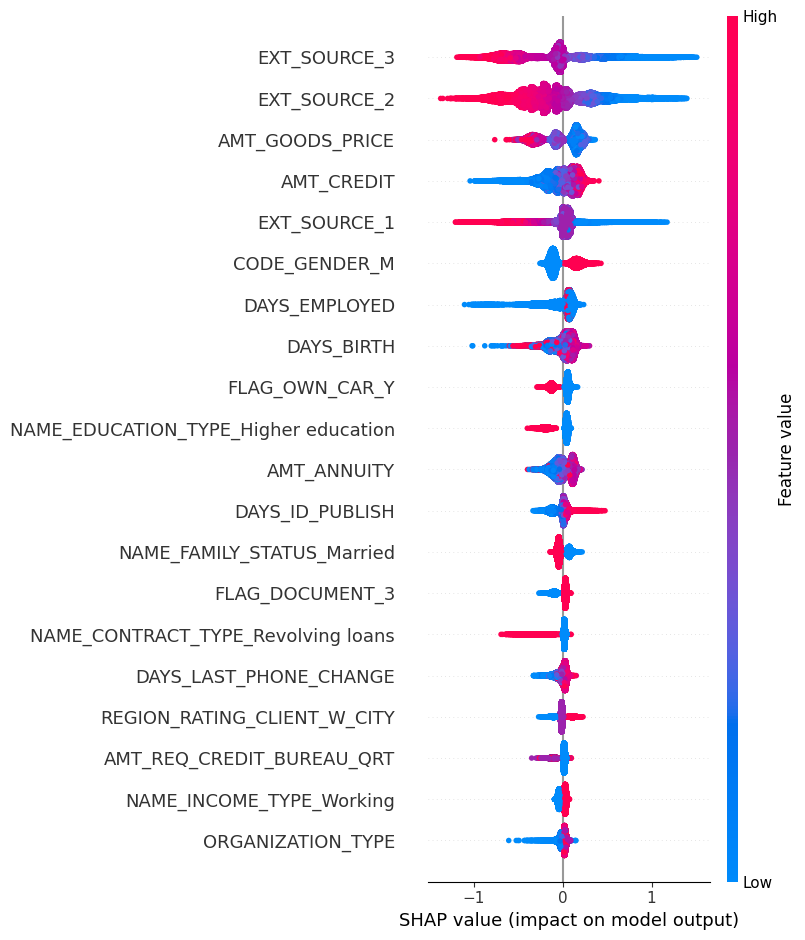

In [13]:
import shap

# Use the tuned model
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

# Global view — which features matter most overall
shap.summary_plot(shap_values, X_test)